In [72]:
from neural_priors.utils.data import Subject
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.odr import ODR, Model, RealData
import os
from pathlib import Path

sns.set_context('poster')

In [74]:
bids_folder = Path('/data/ds-neuralpriors')
fig_folder = bids_folder / 'derivatives' / 'figures' / 'figure2'
os.makedirs(fig_folder, exist_ok=True)

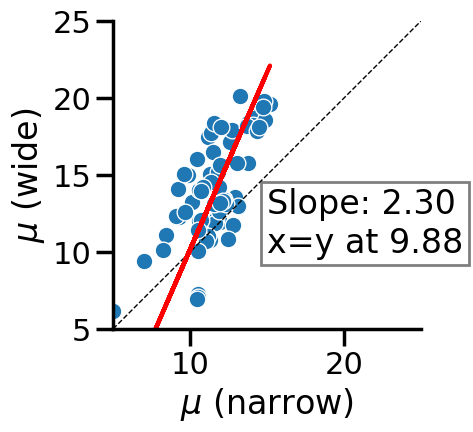

In [174]:
df = Subject('01').get_prf_parameters_volume2(model_label=3, roi='NPCr')
df = df[df[('cvr2', np.nan)] > 0.0]


# Define the linear model
def linear_model(B, x):
    return B[0] * x + B[1]

# Create the model and data
linear = Model(linear_model)
data = RealData(df[('mu', 'narrow')], df[('mu', 'wide')])
# Create the ODR instance and run the regression
odr = ODR(data, linear, beta0=[1., 0.])
output = odr.run()

# Extract the slope and intercept
slope, intercept = output.beta

intersection_x = intersection_y = intercept / (1 - slope)




# Plot the scatter plot
sns.scatterplot(x='narrow', y='wide', data=df['mu'])

# Plot the 1:1 line
plt.plot([5, 25], [5, 25], 'k--', lw=1)

# Plot the estimated line
x_values = df[('mu', 'narrow')]
y_values = slope * x_values + intercept
plt.plot(x_values, y_values, 'r-', label=f'Fitted line: y = {slope:.2f}x + {intercept:.2f}')

# Add text with the estimated slope
# plt.text(min(x_values), max(y_values), f'Slope: {slope:.2f}', color='red')

# Despine the plot
sns.despine()
plt.xlabel('$\mu$ (narrow)')
plt.ylabel('$\mu$ (wide)')

plt.xlim(5, 25)
plt.ylim(5, 25)


plt.annotate(f'Slope: {slope:.2f}\nx=y at {intersection_x:.2f}', xy=(15, 10),
             bbox=dict(facecolor='white', alpha=0.5),)
            #  xy=(intersection_x, intersection_y), xytext=(intersection_x + 1, intersection_y - 1), arrowprops=dict(arrowstyle='->', lw=1.5))

# Make the plot square
plt.gca().set_aspect('equal', adjustable='box')
plt.gcf().set_size_inches(4, 4)
plt.savefig(fig_folder / 'scatter_01.pdf', dpi=300, bbox_inches='tight')

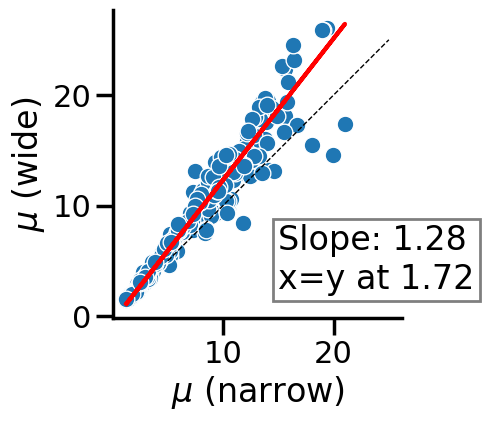

In [175]:
df = Subject('15').get_prf_parameters_volume2(model_label=3, roi='NPCr')
df = df[df[('cvr2', np.nan)] > 0.0]


# Define the linear model
def linear_model(B, x):
    return B[0] * x + B[1]

# Create the model and data
linear = Model(linear_model)
data = RealData(df[('mu', 'narrow')], df[('mu', 'wide')])
# Create the ODR instance and run the regression
odr = ODR(data, linear, beta0=[1., 0.])
output = odr.run()

# Extract the slope and intercept
slope, intercept = output.beta

intersection_x = intersection_y = intercept / (1 - slope)




# Plot the scatter plot
sns.scatterplot(x='narrow', y='wide', data=df['mu'])

# Plot the 1:1 line
plt.plot([5, 25], [5, 25], 'k--', lw=1)

# Plot the estimated line
x_values = df[('mu', 'narrow')]
y_values = slope * x_values + intercept
plt.plot(x_values, y_values, 'r-', label=f'Fitted line: y = {slope:.2f}x + {intercept:.2f}')

# Add text with the estimated slope
# plt.text(min(x_values), max(y_values), f'Slope: {slope:.2f}', color='red')

# Despine the plot
sns.despine()
plt.xlabel('$\mu$ (narrow)')
plt.ylabel('$\mu$ (wide)')

# plt.xlim(5, 25)
# plt.ylim(5, 25)


plt.annotate(f'Slope: {slope:.2f}\nx=y at {intersection_x:.2f}', xy=(15, 2.5),
             bbox=dict(facecolor='white', alpha=0.5),)
            #  xy=(intersection_x, intersection_y), xytext=(intersection_x + 1, intersection_y - 1), arrowprops=dict(arrowstyle='->', lw=1.5))

# Make the plot square
plt.gca().set_aspect('equal', adjustable='box')
plt.gcf().set_size_inches(4, 4)
plt.savefig(fig_folder / 'scatter_15.pdf', dpi=300, bbox_inches='tight')

In [88]:
bids_folder = Path('/data/ds-neuralpriors')
pars = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models2' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars.index.set_names('subject', level='subject_id', inplace=True)
pars = pars.xs(3, level='model_label')
pars = pars[pars[('cvr2', 'nan')] > 0.0]

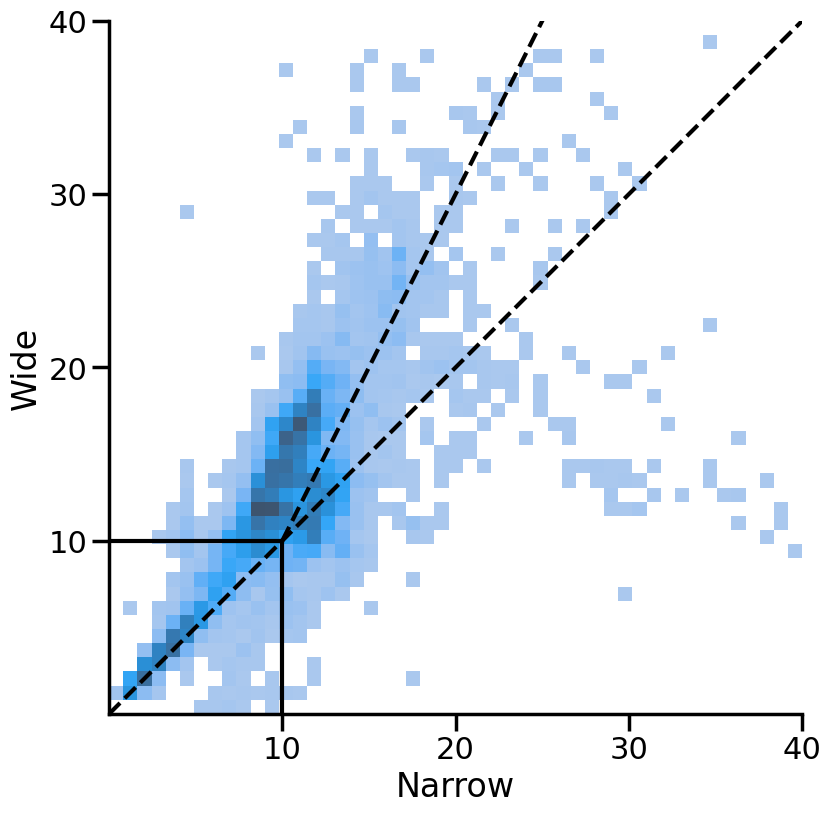

In [119]:
sns.histplot(x='narrow', y='wide', data=pars['mu'], bins=[np.linspace(0, 40), np.linspace(0, 40)])

sns.despine()



slope = 1.
plt.plot([0, 40], [0, 10 + slope*(40-10)], 'k--')
slope = 2.
plt.plot([10, 40], [10, 10 + slope*(40-10)], 'k--')


plt.xlim(0, 40)
plt.ylim(0, 40)


# Make the plot square
plt.gca().set_aspect('equal')

plt.gcf().set_size_inches(9, 9)

plt.xticks([10, 20, 30, 40])
plt.yticks([10, 20, 30, 40])

plt.xlabel('Narrow')
plt.ylabel('Wide')

plt.savefig(fig_folder / 'scatter_group.pdf', dpi=300, bbox_inches='tight')


plt.plot([0, 10], [10, 10], c='k')
plt.plot([10, 10], [0, 10], c='k')

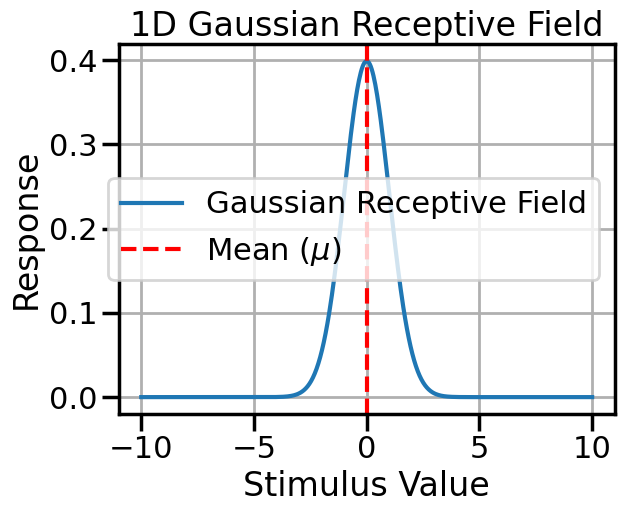

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the Gaussian
mu = 0       # Mean of the Gaussian
sigma = 1    # Standard deviation of the Gaussian
x = np.linspace(-10, 10, 500)  # Range of x values

# Gaussian function
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Plot the Gaussian receptive field
plt.plot(x, gaussian, label='Gaussian Receptive Field')
plt.title('1D Gaussian Receptive Field')
plt.xlabel('Stimulus Value')
plt.ylabel('Response')
plt.axvline(x=mu, color='r', linestyle='--', label='Mean ($\mu$)')
plt.legend()
plt.grid(True)
plt.show()


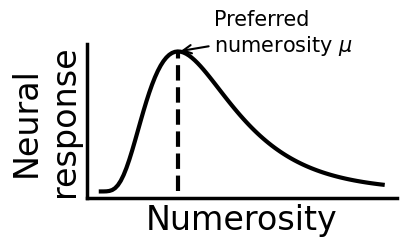

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

# Parameters for the lognormal distribution
s = 0.5  # Shape parameter (sigma)
scale = 15  # Scale parameter

# Define the range of x values
x = np.linspace(1, 40, 100)

# Create the lognormal distribution
dist = ss.lognorm(s=s, scale=scale)

# Calculate the mode
mode = np.exp(np.log(scale) - s**2)

# Plot the lognormal distribution
plt.plot(x, dist.pdf(x), label='Lognormal Receptive Field', c='k')

# Plot a vertical line at the mode
plt.plot([mode, mode], [0, dist.pdf(mode)], 'k--', label=f'Mode: {mode:.2f}')

plt.annotate(f'Preferred\nnumerosity $\mu$', xy=(mode, dist.pdf(mode)), xytext=(mode + 5, dist.pdf(mode)),
             fontsize=15,
             arrowprops=dict(arrowstyle='->', lw=1.5, color='k'))

plt.xlabel('Numerosity')

plt.ylabel('Neural\nresponse')

# Customize the plot
plt.xticks([])
plt.yticks([])
sns.despine()

plt.gcf().set_size_inches(4, 2)

plt.savefig(fig_folder / 'lognormal.pdf', dpi=300, bbox_inches='tight')